In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
FIT = FitSpectrum()
DP = DP()

dps_df, model_1comp, left_2comp, right_2comp = DP.extract_fits_data('./catalogs/0430_dps_test.fits')
# dps_df = dps_df[dps_df['BPT_1COMP']==16].copy()
ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=dps_df['TARGETID'].to_list(), subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 7.34 seconds.
Total number of spectra: 25767


In [1212]:
# test_idx = dps_df[dps_df['TARGETID'] == 39627805952053484].index[0]
test_idx = np.random.randint(0, len(ALL_SPECTRA.df))
test_id = ALL_SPECTRA.df.iloc[test_idx]["TARGETID"]
# print(f'TARGETID: {test_id}')
lam = desi_wavelength / (1+ALL_SPECTRA.df.iloc[test_idx]['Z'])

In [1213]:
test_df = ALL_SPECTRA.df.iloc[test_idx]
print(test_df)

TARGETID    39627764122258834
RA                  211.93825
DEC                 -0.970689
Z                    0.160792
SPECTYPE               GALAXY
LOGM                10.169693
LOGSFR               1.205697
Name: 7645, dtype: object


In [1214]:
params_1comp, (combine_lam, combine_flux, combine_sigma, combine_model_1), slice_indices, _, conti_adjs = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=None, w_dz=False, n_components=1)
model_1comp = np.sum([
    model_vel(lam, gaussian_parms=params_1comp['gaussian_params'][i]) for i in range(len(params_1comp['gaussian_params']))
], axis=0)

params_2comp, (combine_lam, combine_flux, combine_sigma, combine_model_2), _, _, conti_adjs = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=None, w_dz=False, n_components=2)
model_2comp = np.sum([
    model_vel(lam, gaussian_parms=params_2comp['gaussian_params'][i]) for i in range(len(params_2comp['gaussian_params']))
], axis=0)

params_3comp, (combine_lam, combine_flux, combine_sigma, combine_model_3), _, _, conti_adjs = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=None, w_dz=False, n_components=3)
model_3comp = np.sum([
    model_vel(lam, gaussian_parms=params_3comp['gaussian_params'][i]) for i in range(len(params_3comp['gaussian_params']))
], axis=0)

params_4comp, (combine_lam, combine_flux, combine_sigma, combine_model_4), _, _, conti_adjs = FIT.fit_multi_emission_vel(data_class=ALL_SPECTRA, id=test_id, two_component=None, w_dz=False, n_components=4)
model_4comp = np.sum([
    model_vel(lam, gaussian_parms=params_4comp['gaussian_params'][i]) for i in range(len(params_4comp['gaussian_params']))
], axis=0)

In [1215]:
adjustment = np.split(np.ones(len(combine_flux)), slice_indices)
for i in range(len(adjustment)):
    adjustment[i] *= conti_adjs[i]
adjustment = np.concatenate(adjustment)

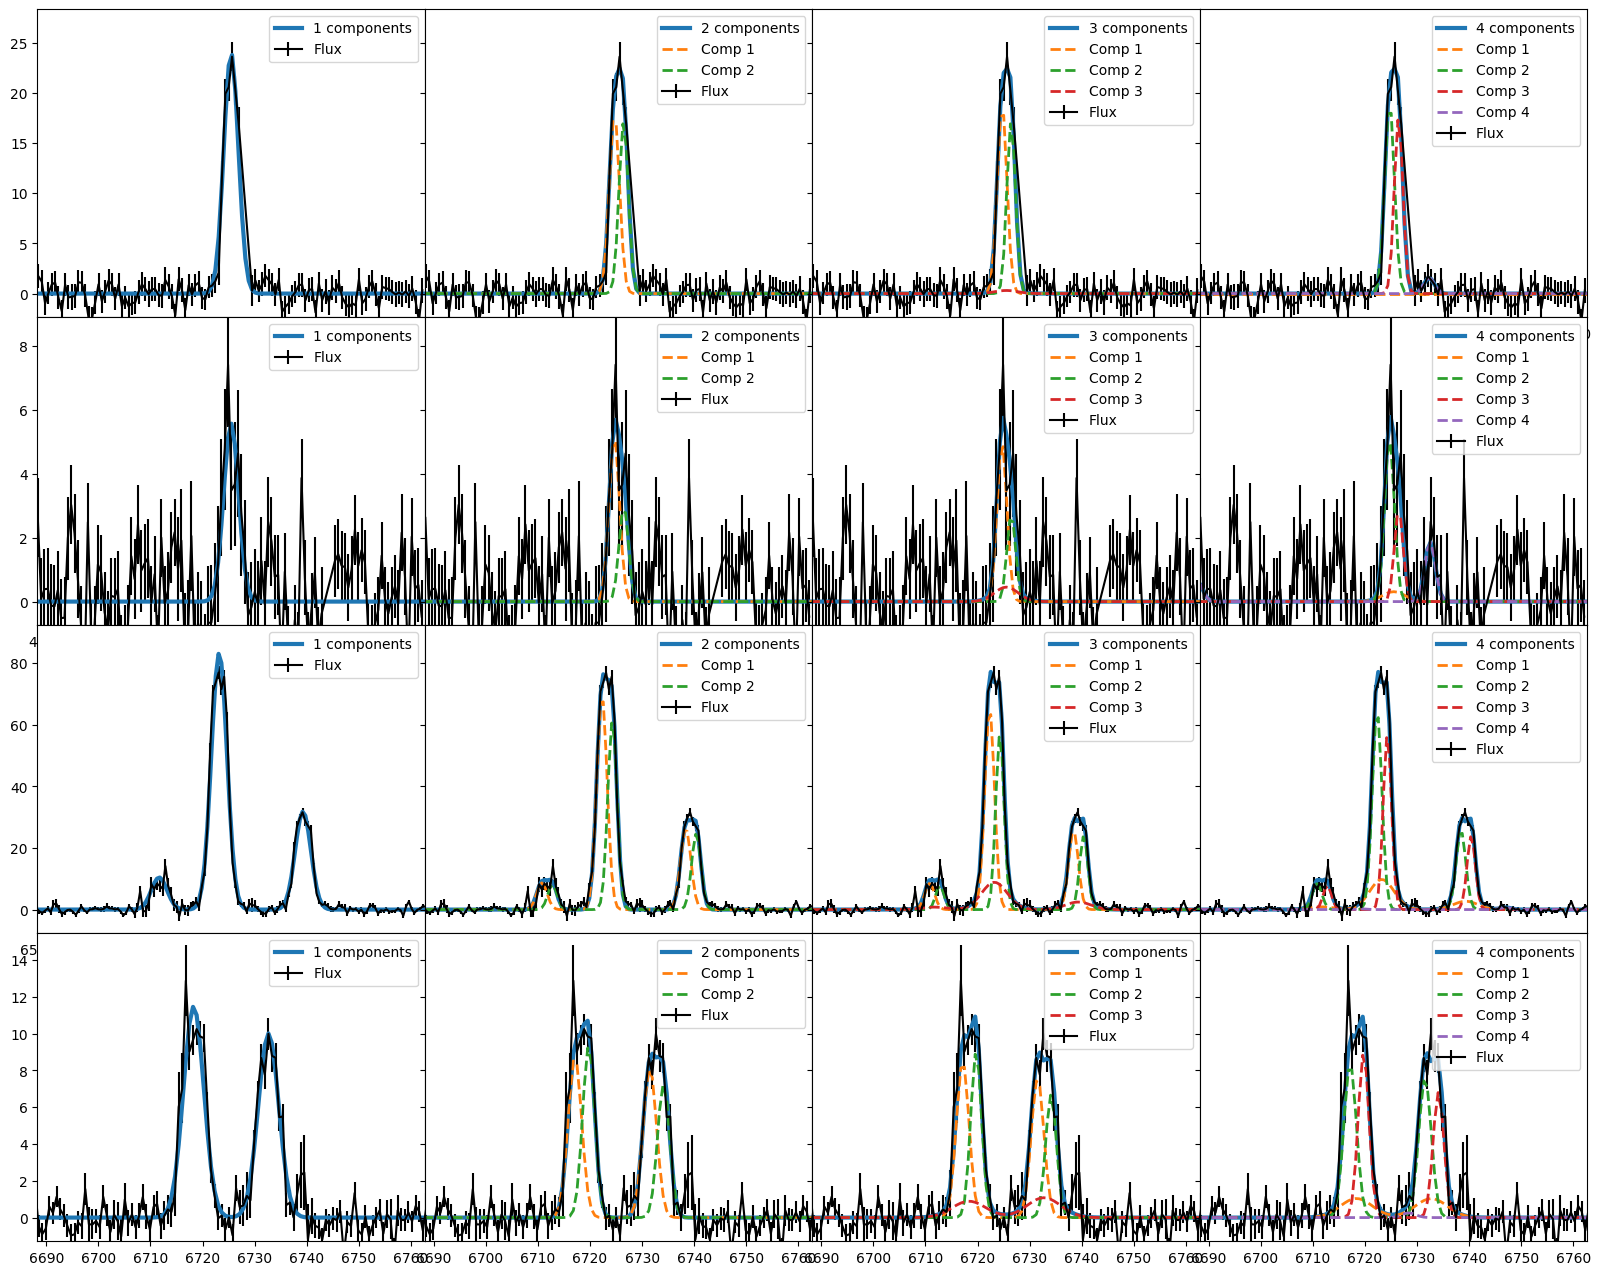

In [1216]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16), sharey='row')
plt.subplots_adjust(wspace=0., hspace=0.)

lam_split  = np.split(combine_lam, slice_indices)
flux_split = np.split(combine_flux, slice_indices)
sigma_split = np.split(combine_sigma, slice_indices)


for i, (model, param) in enumerate(zip([model_1comp, model_2comp, model_3comp, model_4comp], [params_1comp, params_2comp, params_3comp, params_4comp])):
    
        
    ax = axes[0, i]
    ax.errorbar(lam_split[1], flux_split[1], yerr=sigma_split[1], label='Flux', color='k')
    ax.plot(lam, model, label=f'{i+1} components', lw=3)
    if i !=0:
        for j in range(len(param['components'])):
            comp = np.sum([
                model_vel(lam, gaussian_parms=param['components'][j]['gaussian_params'][k]) for k in range(len(param['components'][j]['gaussian_params']))
            ], axis=0)
            ax.plot(lam, comp, label=f'Comp {j+1}', lw=2, ls='--')
    ax.set_xlim((Hbeta_rest[0]-40, Hbeta_rest[0]+40))
    ax.set_ylim(bottom=-np.max(flux_split[1])*0.1, top=np.max(flux_split[1])*1.2)
    ax.legend()
    
    ax = axes[1, i]
    ax.errorbar(lam_split[2], flux_split[2], yerr=sigma_split[2], label='Flux', color='k')
    ax.plot(lam, model, label=f'{i+1} components', lw=3)
    if i !=0:
        for j in range(len(param['components'])):
            comp = np.sum([
                model_vel(lam, gaussian_parms=param['components'][j]['gaussian_params'][k]) for k in range(len(param['components'][j]['gaussian_params']))
            ], axis=0)
            ax.plot(lam, comp, label=f'Comp {j+1}', lw=2, ls='--')
    ax.set_xlim((OIII_rest[1]-40, OIII_rest[1]+40))
    ax.set_ylim(bottom=-np.max(flux_split[2])*0.1, top=np.max(flux_split[2])*1.2)
    ax.legend()
    
    
    ax = axes[2, i]
    ax.errorbar(lam_split[3], flux_split[3], yerr=sigma_split[3], label='Flux', color='k')
    ax.plot(lam, model, label=f'{i+1} components', lw=3)
    if i !=0:
        for j in range(len(param['components'])):
            comp = np.sum([
                model_vel(lam, gaussian_parms=param['components'][j]['gaussian_params'][k]) for k in range(len(param['components'][j]['gaussian_params']))
            ], axis=0)
            ax.plot(lam, comp, label=f'Comp {j+1}', lw=2, ls='--')
    ax.set_xlim((NII_rest[0]-30, NII_rest[1]+30))
    ax.set_ylim(bottom=-np.max(flux_split[3])*0.1, top=np.max(flux_split[3])*1.2)
    ax.legend()
    
    ax = axes[3, i]
    ax.errorbar(lam_split[4], flux_split[4], yerr=sigma_split[4], label='Flux', color='k')
    ax.plot(lam, model, label=f'{i+1} components', lw=3)
    if i !=0:
        for j in range(len(param['components'])):
            comp = np.sum([
                model_vel(lam, gaussian_parms=param['components'][j]['gaussian_params'][k]) for k in range(len(param['components'][j]['gaussian_params']))
            ], axis=0)
            ax.plot(lam, comp, label=f'Comp {j+1}', lw=2, ls='--')
    ax.set_xlim((SII_rest[0]-30, SII_rest[1]+30))
    ax.set_ylim(bottom=-np.max(flux_split[4])*0.1, top=np.max(flux_split[4])*1.2)
    ax.legend()
    
plt.show()

In [1217]:
print(params_4comp['dv'])
print(params_4comp['sigma'])

(np.float64(2.2154014212198194), np.float64(-51.47069029345887), np.float64(63.82242236258751), np.float64(451.54877348558176))
(np.float64(133.88375023796618), np.float64(44.11555562901454), np.float64(35.094362113839885), np.float64(50.36250970642344))


In [1218]:
print(params_3comp['dv'])
print(params_3comp['sigma'])

(np.float64(-51.0652735269594), np.float64(64.20836064413884), np.float64(2.9493953714636567))
(np.float64(44.693895341401095), np.float64(34.99573103361949), np.float64(140.57557620857943))


In [1219]:
print(params_2comp['dv'])
print(params_2comp['sigma'])

(np.float64(-53.6399276858753), np.float64(64.50784768141821))
(np.float64(49.409250770920785), np.float64(41.86484805297253))


In [1220]:
print(params_1comp['sigma'])

82.47045070148683


In [1221]:
# Hbeta = np.array(params_4comp['amps'][1:-1][0])
# OIII = np.array(params_4comp['amps'][1:-1][1][1::2])
# Halpha = np.array(params_4comp['amps'][1:-1][2][8:])
# NII = np.array(params_4comp['amps'][1:-1][2][:8][1::2])
# logoiii_hb = np.log10(OIII / Hbeta)
# lognii_ha = np.log10(NII / Halpha)

In [1222]:
# Hbeta = np.array(params_3comp['amps'][1:-1][0])
# OIII = np.array(params_3comp['amps'][1:-1][1][1::2])
# Halpha = np.array(params_3comp['amps'][1:-1][2][6:])
# NII = np.array(params_3comp['amps'][1:-1][2][:6][1::2])
# logoiii_hb = np.log10(OIII / Hbeta)
# lognii_ha = np.log10(NII / Halpha)

In [1223]:
# Hbeta = np.array(params_2comp['amps'][1:-1][0])
# OIII = np.array(params_2comp['amps'][1:-1][1][1::2])
# Halpha = np.array(params_2comp['amps'][1:-1][2][4:])
# NII = np.array(params_2comp['amps'][1:-1][2][:4][1::2])
# logoiii_hb = np.log10(OIII / Hbeta)
# lognii_ha = np.log10(NII / Halpha)

In [1224]:
# Hbeta = np.array(params_1comp['amps'][1:-1][0])
# OIII = np.array(params_1comp['amps'][1:-1][1][1])
# Halpha = np.array(params_1comp['amps'][1:-1][2][2])
# NII = np.array(params_1comp['amps'][1:-1][2][1])

In [1225]:
# for i in range(len(lognii_ha)):
#     plt.scatter(lognii_ha[i], logoiii_hb[i], c=['C1', 'C2', 'C3', 'C4'][i], s=10)

# x = np.linspace(-4, 1, 500)
# sf_boundary = 0.61/(x-0.05) + 1.30
# comp_boundary = 0.61/(x-0.47) + 1.19
# liner_boundary = 1.05*x + 0.45
# plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], c='red')
# plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], c='orange')
# plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], c='green')
# plt.xlim((-2, 0.75))
# plt.ylim((-2, 2.5))
# plt.show()

Best model: 2-Component

Delta BIC relative to best model:
1-Component: Delta BIC = 99.5127
2-Component: Delta BIC = 0.0000
3-Component: Delta BIC = 25.5367
4-Component: Delta BIC = 72.4006


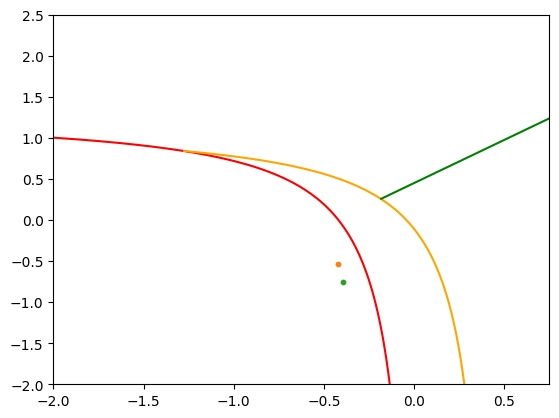

In [1226]:
# Calculate BIC for each model

n_data = len(combine_lam)

# Calculate chi-squared for each model
chisq_1comp = np.sum((combine_flux - combine_model_1)**2 / combine_sigma**2)
chisq_2comp = np.sum((combine_flux - combine_model_2)**2 / combine_sigma**2)
chisq_3comp = np.sum((combine_flux - combine_model_3)**2 / combine_sigma**2)
chisq_4comp = np.sum((combine_flux - combine_model_4)**2 / combine_sigma**2)

# Number of parameters for each model
k_1comp = 9
k_2comp = 18
k_3comp = 27
k_4comp = 36

# Calculate BIC
bic_1comp = k_1comp * np.log(n_data) + chisq_1comp
bic_2comp = k_2comp * np.log(n_data) + chisq_2comp
bic_3comp = k_3comp * np.log(n_data) + chisq_3comp
bic_4comp = k_4comp * np.log(n_data) + chisq_4comp

# Print results
# print(f"Number of data points: {n_data}")
# print(f"1-Component Model:")
# print(f"  Parameters: {k_1comp}, Chi-squared: {chisq_1comp:.4e}, reduced: {chisq_1comp/(n_data-k_1comp):.4e}, BIC: {bic_1comp:.4f}\n")
# print(f"2-Component Model:")
# print(f"  Parameters: {k_2comp}, Chi-squared: {chisq_2comp:.4e}, reduced: {chisq_2comp/(n_data-k_2comp):.4e}, BIC: {bic_2comp:.4f}\n")
# print(f"3-Component Model:")
# print(f"  Parameters: {k_3comp}, Chi-squared: {chisq_3comp:.4e}, reduced: {chisq_3comp/(n_data-k_3comp):.4e}, BIC: {bic_3comp:.4f}\n")
# print(f"4-Component Model:")
# print(f"  Parameters: {k_4comp}, Chi-squared: {chisq_4comp:.4e}, reduced: {chisq_4comp/(n_data-k_4comp):.4e}, BIC: {bic_4comp:.4f}\n")

# Find best model (lowest BIC)
bic_values = np.array([bic_1comp, bic_2comp, bic_3comp, bic_4comp])
best_model = np.argmin(bic_values) + 1
delta_bic = bic_values - np.min(bic_values)

print(f"Best model: {best_model}-Component")
print("\nDelta BIC relative to best model:")

for i, dbic in enumerate(delta_bic, start=1):
    print(f"{i}-Component: Delta BIC = {dbic:.4f}")

# best_model=3

if best_model == 1:
    Hbeta = np.array(params_1comp['amps'][1:-1][0])
    OIII = np.array(params_1comp['amps'][1:-1][1][1])
    Halpha = np.array(params_1comp['amps'][1:-1][2][2])
    NII = np.array(params_1comp['amps'][1:-1][2][1])
elif best_model == 2:
    Hbeta = np.array(params_2comp['amps'][1:-1][0])
    OIII = np.array(params_2comp['amps'][1:-1][1][1::2])
    Halpha = np.array(params_2comp['amps'][1:-1][2][4:])
    NII = np.array(params_2comp['amps'][1:-1][2][:4][1::2])
elif best_model == 3:
    Hbeta = np.array(params_3comp['amps'][1:-1][0])
    OIII = np.array(params_3comp['amps'][1:-1][1][1::2])
    Halpha = np.array(params_3comp['amps'][1:-1][2][6:])
    NII = np.array(params_3comp['amps'][1:-1][2][:6][1::2])
elif best_model == 4:
    Hbeta = np.array(params_4comp['amps'][1:-1][0])
    OIII = np.array(params_4comp['amps'][1:-1][1][1::2])
    Halpha = np.array(params_4comp['amps'][1:-1][2][8:])
    NII = np.array(params_4comp['amps'][1:-1][2][:8][1::2])

logoiii_hb = np.log10(OIII / Hbeta)
lognii_ha = np.log10(NII / Halpha)
if best_model != 1:
    for i in range(len(lognii_ha)):
        plt.scatter(lognii_ha[i], logoiii_hb[i], c=['C1', 'C2', 'C3', 'C4'][i], s=10)
else:
    plt.scatter(lognii_ha, logoiii_hb, c='C0', s=10)

x = np.linspace(-4, 1, 500)
sf_boundary = 0.61/(x-0.05) + 1.30
comp_boundary = 0.61/(x-0.47) + 1.19
liner_boundary = 1.05*x + 0.45
plt.plot(x[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], sf_boundary[(x<0.05)|((sf_boundary<comp_boundary)&(sf_boundary<liner_boundary))], c='red')
plt.plot(x[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], comp_boundary[(x<0.47)&(comp_boundary>sf_boundary)|(comp_boundary<liner_boundary)], c='orange')
plt.plot(x[(x>0)|(liner_boundary>comp_boundary)], liner_boundary[(x>0)|(liner_boundary>comp_boundary)], c='green')
plt.xlim((-2, 0.75))
plt.ylim((-2, 2.5))
plt.show()

In [1227]:
from scipy.stats import f

F_stat_12 = ((chisq_1comp - chisq_2comp) / (k_2comp-k_1comp)) / (chisq_2comp / (n_data-k_2comp))
p_value_12 = 1 - f.cdf(F_stat_12, k_2comp-k_1comp, n_data-k_2comp)
if p_value_12 > 0.05:
    print("1-Component")
else:
    F_stat_23 = ((chisq_2comp - chisq_3comp) / (k_3comp-k_2comp)) / (chisq_3comp / (n_data-k_3comp))
    p_value_23 = 1 - f.cdf(F_stat_23, k_3comp-k_2comp, n_data-k_3comp)
    if p_value_23 > 0.05:
        print("2-Component")
    else:
        F_stat_34 = ((chisq_3comp - chisq_4comp) / (k_4comp-k_3comp)) / (chisq_4comp / (n_data-k_4comp))
        p_value_34 = 1 - f.cdf(F_stat_34, k_4comp-k_3comp, n_data-k_4comp)
        if p_value_34 > 0.05:
            print("3-Component")
        else:
            print("4-Component")



3-Component
